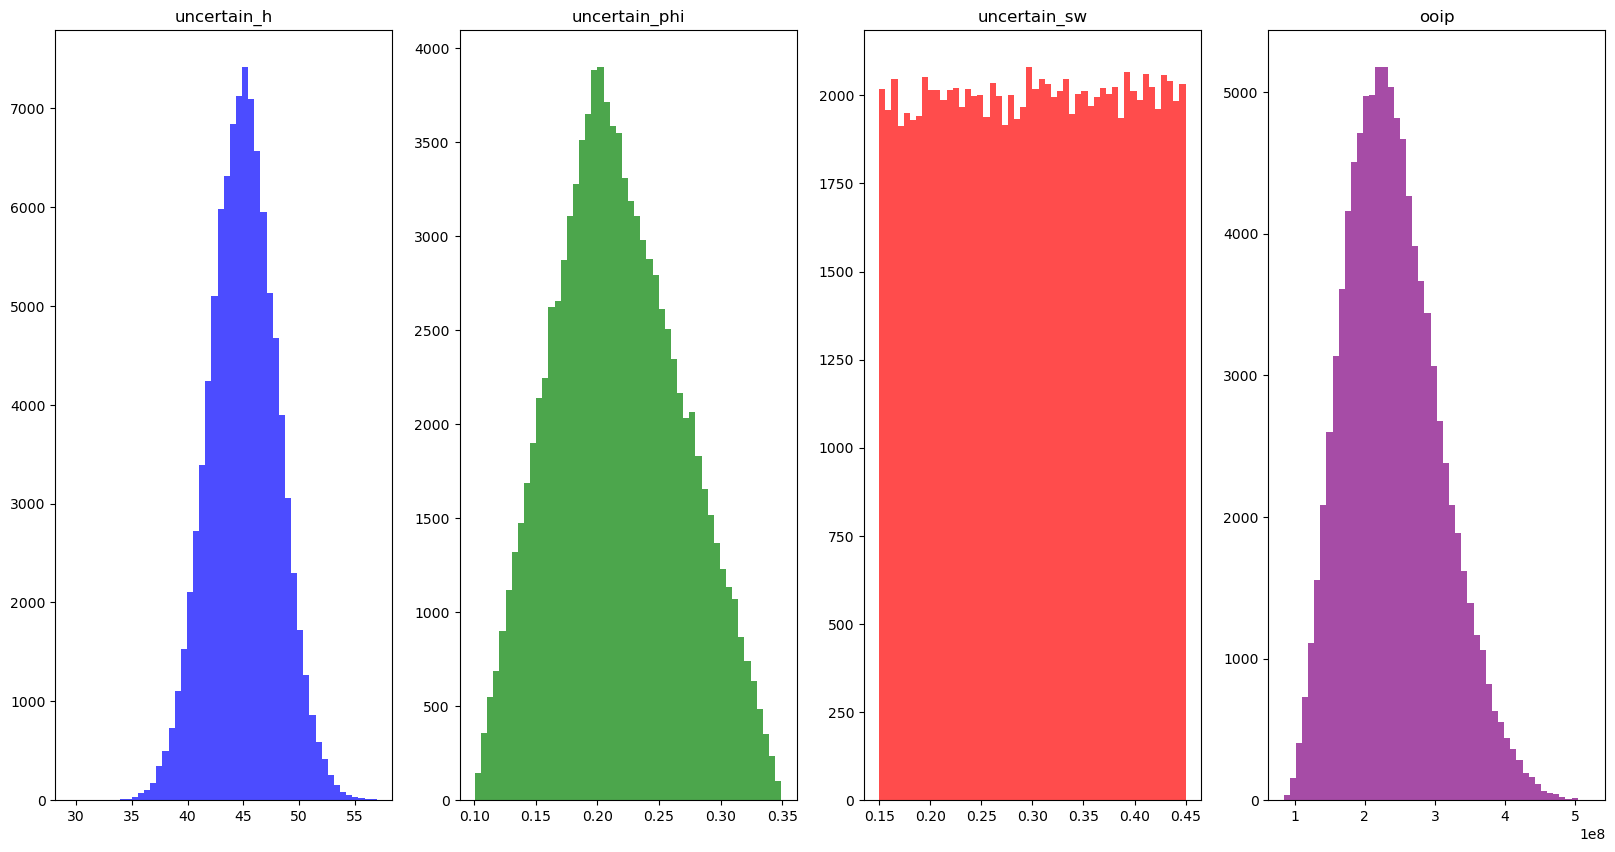

In [9]:
import numpy as np # to generate random values based on distribution
import pandas as pd # to generate table based on random values
import matplotlib.pyplot as plt

area = 5000 #acres
boi = 1.1 # rb/stb

cases = 100000
uncertain_h = np.random.normal(loc=45, scale=3, size=cases) # loc = mean, scale = stddev
uncertain_phi = np.random.triangular(left=0.1, mode=0.2, right=0.35, size=cases) # left = min, mode = most likely, right = max
uncertain_sw = np.random.uniform(low=0.15, high=0.45, size=cases) # uniform distribution between 0.15 and 0.45

# how to generte a table
# 1 - create a dictionary
data = dict(h=uncertain_h, phi=uncertain_phi, sw=uncertain_sw)
# 2 - create a dataframe
sim_data = pd.DataFrame(data)
reserve = 7758 * area * sim_data['h'] * sim_data['phi'] * (1 - sim_data['sw'])/boi
sim_data['ooip'] = reserve
sim_data
# export to csv
sim_data.to_csv('monte_carlo_simulation_results.csv')

# histogram (create the plot or subplot)
fig, ax = plt.subplots(ncols=4, figsize=(20,10))
ax[0].hist(sim_data['h'], bins=50, color='blue', alpha=0.7)
ax[0].set_title('uncertain_h')

ax[1].hist(sim_data['phi'], bins=50, color='green', alpha=0.7)
ax[1].set_title('uncertain_phi')

ax[2].hist(sim_data['sw'], bins=50, color='red', alpha=0.7)
ax[2].set_title('uncertain_sw')

ax[3].hist(sim_data['ooip'], bins=50, color='purple', alpha=0.7)
ax[3].set_title('ooip')

fig.savefig('monte_carlo_simulation_histograms.png')

In [ ]:
# multi rate testing